In [ ]:

import pandas as pd

path = "ALL_3.csv"
df = pd.read_csv(path)

df.shape


(39509, 2)

In [ ]:
import pandas as pd



# --- Функция определения новости про Nvidia ---
def is_nvidia(text):
    text = str(text).lower()

    keywords = [
        "nvidia", "nvda", "geforce", "gpu", "cuda",
        "h100", "a100", "blackwell", "tensor core",
        "rtx", "graphics card", "chipmaker nvidia"
    ]

    return int(any(kw in text for kw in keywords))


# --- Создание лейбла belongs_to_nvidia ---
df["belongs_to_nvidia"] = df["Title"].apply(is_nvidia)


# Проверка распределения
print(df["belongs_to_nvidia"].value_counts())

# Сохраняем
df.to_csv("ALL_3_labeled.csv", index=False)

print("Лейбл belongs_to_nvidia успешно создан!")


belongs_to_nvidia
0    30767
1     8742
Name: count, dtype: int64
Лейбл belongs_to_nvidia успешно создан!


In [ ]:
df.info
df.to_csv("Nvidi.CSV")

In [ ]:
!pip install transformers
!pip install torch


   ---------------------------------------- 0.0/12.0 MB ? eta -:--:--
   ----- ---------------------------------- 1.6/12.0 MB 8.2 MB/s eta 0:00:02
   ----------- ---------------------------- 3.4/12.0 MB 8.3 MB/s eta 0:00:02
   ----------------- ---------------------- 5.2/12.0 MB 8.3 MB/s eta 0:00:01
   ---------------------- ----------------- 6.8/12.0 MB 8.3 MB/s eta 0:00:01
   ---------------------------- ----------- 8.7/12.0 MB 8.3 MB/s eta 0:00:01
   ---------------------------------- ----- 10.2/12.0 MB 8.3 MB/s eta 0:00:01
   ---------------------------------------  11.8/12.0 MB 8.3 MB/s eta 0:00:01
   ---------------------------------------- 12.0/12.0 MB 8.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/566.1 kB ? eta -:--:--
   ---------------------------------------- 566.1/566.1 kB 7.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ----------------------- ---------------- 1.6/2.7 MB 8.2 MB/s eta 0:00:01
   ------------

In [ ]:
import pandas as pd

df = pd.read_csv("ALL_3_labeled.csv")

# === 1. Универсальное превращение строки в datetime ===

def clean_date(x):
    x = str(x).strip()

    # 1) Если строка длинная и похожа на timestamp: 20230507T153709
    if "T" in x:
        try:
            return pd.to_datetime(x, format="%Y%m%dT%H%M%S", errors="coerce")
        except:
            pass

    # 2) Если строка формата YYYYMMDD без разделителей
    if len(x) == 8 and x.isdigit():
        try:
            return pd.to_datetime(x, format="%Y%m%d", errors="coerce")
        except:
            pass

    # 3) Если обычная дата с дефисами или слешами
    try:
        return pd.to_datetime(x, errors="coerce")
    except:
        return pd.NaT


df["date"] = df["Date"].apply(clean_date)   # если у тебя колонка называется Date


In [ ]:
df = df.dropna(subset=["date"]).reset_index(drop=True)


In [ ]:
df["date_only"] = df["date"].dt.date


In [ ]:
df = df.sort_values(by="date_only")


In [ ]:
df.to_csv("ALL_3_clean_dates.csv", index=False)
print("Даты успешно приведены к нормальному формату!")


Даты успешно приведены к нормальному формату!


In [ ]:
import re
import pandas as pd

df = pd.read_csv("ALL_3_clean_dates.csv")


In [ ]:
def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text)

    # 1. Удаляем ссылки
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # 2. Удаляем HTML-теги
    text = re.sub(r"<.*?>", "", text)

    # 3. Удаляем спецсимволы
    text = re.sub(r"[^A-Za-zА-Яа-я0-9\s\.,\-]", " ", text)

    # 4. Удаляем лишние пробелы
    text = re.sub(r"\s+", " ", text)

    # 5. Обрезаем лишние пробелы
    text = text.strip()

    return text


In [ ]:
df["clean_text"] = df["Title"].apply(clean_text)


In [ ]:
df = df[df["clean_text"].str.len() > 3].reset_index(drop=True)


In [ ]:
df = df.drop_duplicates(subset=["clean_text"])


In [ ]:
df["clean_text"] = df["clean_text"].str.slice(0, 300)


In [ ]:
df.to_csv("ALL_3_ready_for_finbert.csv", index=False)
print("Данные успешно очищены и готовы для FinBERT!")
print("Min date:", df["date"].min())
print("Max date:", df["date"].max())



Данные успешно очищены и готовы для FinBERT!
Min date: 2023-05-01 00:00:00
Max date: 2025-04-05 19:31:48


In [ ]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from tqdm import tqdm


In [ ]:
df = pd.read_csv("ALL_3_ready_for_finbert.csv")

print(df.head())
print(df.columns)


                                               Title             Date  \
0  Wall Street near flat after First Republic new...       2023-05-01   
1  Here's how Micron's stock soared in March 2024...  20230501T210320   
2  April 4, 2024 ( Investorideas.com Newswire ) I...  20230501T203000   
3  Nvidia Corp and Alphabet Inc saw the biggest j...  20230501T202600   
4  Vuzix (VUZI) enters into a reseller agreement ...  20230501T201300   

   belongs_to_nvidia                 date   date_only  \
0                  0  2023-05-01 00:00:00  2023-05-01   
1                  0  2023-05-01 21:03:20  2023-05-01   
2                  0  2023-05-01 20:30:00  2023-05-01   
3                  1  2023-05-01 20:26:00  2023-05-01   
4                  0  2023-05-01 20:13:00  2023-05-01   

                                          clean_text  
0  Wall Street near flat after First Republic new...  
1  Here s how Micron s stock soared in March 2024...  
2  April 4, 2024 Investorideas.com Newswire Inves... 

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")

labels = ["negative", "neutral", "positive"]


In [ ]:
def get_finbert_sentiment(text):
    try:
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1)
        probs_np = probs.detach().numpy()[0]

        label = labels[probs_np.argmax()]
        neg, neu, pos = probs_np[0], probs_np[1], probs_np[2]

        return label, neg, neu, pos

    except:
        return "neutral", 0.33, 0.33, 0.33


In [ ]:
sentiment_labels = []
neg_list = []
neu_list = []
pos_list = []

for text in tqdm(df["clean_text"], desc="Processing FinBERT"):
    label, neg, neu, pos = get_finbert_sentiment(str(text))
    sentiment_labels.append(label)
    neg_list.append(neg)
    neu_list.append(neu)
    pos_list.append(pos)


Processing FinBERT: 100%|██████████████████████████████████████████████████████| 34863/34863 [1:06:30<00:00,  8.74it/s]


In [ ]:
df["sentiment_label"] = sentiment_labels
df["sent_neg"] = neg_list
df["sent_neu"] = neu_list
df["sent_pos"] = pos_list


In [ ]:
df.to_csv("ALL_3_finbert_sentiment.csv", index=False)
print("FinBERT sentiment analysis completed and saved!")


FinBERT sentiment analysis completed and saved!


In [ ]:
df["sentiment_label"].value_counts()


sentiment_label
positive    14005
negative    12525
neutral      8333
Name: count, dtype: int64

In [ ]:
df.groupby("belongs_to_nvidia")["sentiment_label"].value_counts()


belongs_to_nvidia  sentiment_label
0                  positive           10956
                   negative            9146
                   neutral             6557
1                  negative            3379
                   positive            3049
                   neutral             1776
Name: count, dtype: int64

In [ ]:
df.groupby("belongs_to_nvidia")[["sent_neg","sent_neu","sent_pos"]].mean()


,sent_neg,sent_neu,sent_pos
belongs_to_nvidia,,,
0,0.349554,0.250733,0.399712
1,0.402440,0.221359,0.376201


⭐ 1. Создать дневную агрегацию FinBERT sentiment

Это критически важно, потому что потом мы будем:

объединять с дневной ценой NVDA

находить лаги

строить AI-Hype Index

делать Granger causality

In [ ]:
df_daily = df.groupby(["date_only", "belongs_to_nvidia"])[["sent_neg","sent_neu","sent_pos"]].mean().reset_index()
df_daily.head()


,date_only,belongs_to_nvidia,sent_neg,sent_neu,sent_pos
0,2023-05-01,0,0.434308,0.196796,0.368896
1,2023-05-01,1,0.684974,0.040084,0.274942
2,2023-05-02,0,0.363880,0.335283,0.300836
3,2023-05-02,1,0.338000,0.304340,0.357661
4,2023-05-03,0,0.192913,0.430930,0.376157


⭐ 2. Разделить два индекса:
1️⃣ NVIDIA Sentiment Index

Все новости, где belongs_to_nvidia = 1 2️⃣ подругому называется экстернал анализ

Все новости, где belongs_to_nvidia = 0

In [ ]:
nvidia_daily = df_daily[df_daily["belongs_to_nvidia"] == 1].copy()
external_daily = df_daily[df_daily["belongs_to_nvidia"] == 0].copy()


⭐ 3. Создать sentiment score = positive – negative

Это классический финансовый sentiment index.

In [ ]:
nvidia_daily["sent_score"] = nvidia_daily["sent_pos"] - nvidia_daily["sent_neg"]
external_daily["sent_score"] = external_daily["sent_pos"] - external_daily["sent_neg"]


In [ ]:

external_daily.columns

Index(['date_only', 'belongs_to_nvidia', 'sent_neg', 'sent_neu', 'sent_pos',
       'sent_score'],
      dtype='object')

In [ ]:
nvidia_daily.to_csv("NVIDIA_sentiment_daily.csv", index=False)
external_daily.to_csv("External Market Sentiment Index.csv", index=False)


In [ ]:
print("external_daily columns:", external_daily.columns.tolist())
print("nvidia_daily columns:", nvidia_daily.columns.tolist())

external_daily = external_daily.reset_index()

print("external_daily columns:", external_daily.columns.tolist())



external_daily columns: ['date_only', 'belongs_to_nvidia', 'sent_neg', 'sent_neu', 'sent_pos', 'sent_score']
nvidia_daily columns: ['date_only', 'belongs_to_nvidia', 'sent_neg', 'sent_neu', 'sent_pos', 'sent_score']
external_daily columns: ['index', 'date_only', 'belongs_to_nvidia', 'sent_neg', 'sent_neu', 'sent_pos', 'sent_score']


In [ ]:
external_daily.head

<bound method NDFrame.head of      index   date_only  belongs_to_nvidia  sent_neg  sent_neu  sent_pos  \
0        0  2023-05-01                  0  0.434308  0.196796  0.368896   
1        2  2023-05-02                  0  0.363880  0.335283  0.300836   
2        4  2023-05-03                  0  0.192913  0.430930  0.376157   
3        6  2023-05-04                  0  0.373011  0.236866  0.390123   
4        8  2023-05-05                  0  0.233345  0.299414  0.467241   
..     ...         ...                ...       ...       ...       ...   
697   1385  2025-04-01                  0  0.407543  0.237444  0.355012   
698   1387  2025-04-02                  0  0.195753  0.389662  0.414585   
699   1389  2025-04-03                  0  0.378960  0.280371  0.340669   
700   1391  2025-04-04                  0  0.168852  0.576814  0.254333   
701   1393  2025-04-05                  0  0.181836  0.512219  0.305945   

     sent_score  
0     -0.065412  
1     -0.063044  
2      0.183244

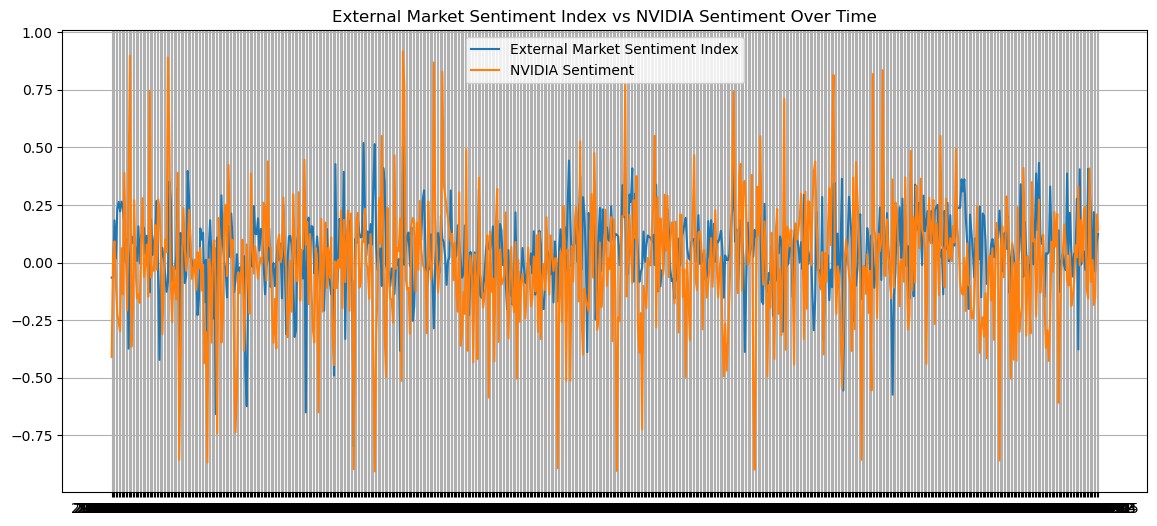

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(external_daily["date_only"], external_daily["sent_score"], label="External Market Sentiment Index")
plt.plot(nvidia_daily["date_only"], nvidia_daily["sent_score"], label="NVIDIA Sentiment")
plt.legend()
plt.title("External Market Sentiment Index vs NVIDIA Sentiment Over Time")
plt.grid(True)
plt.show()


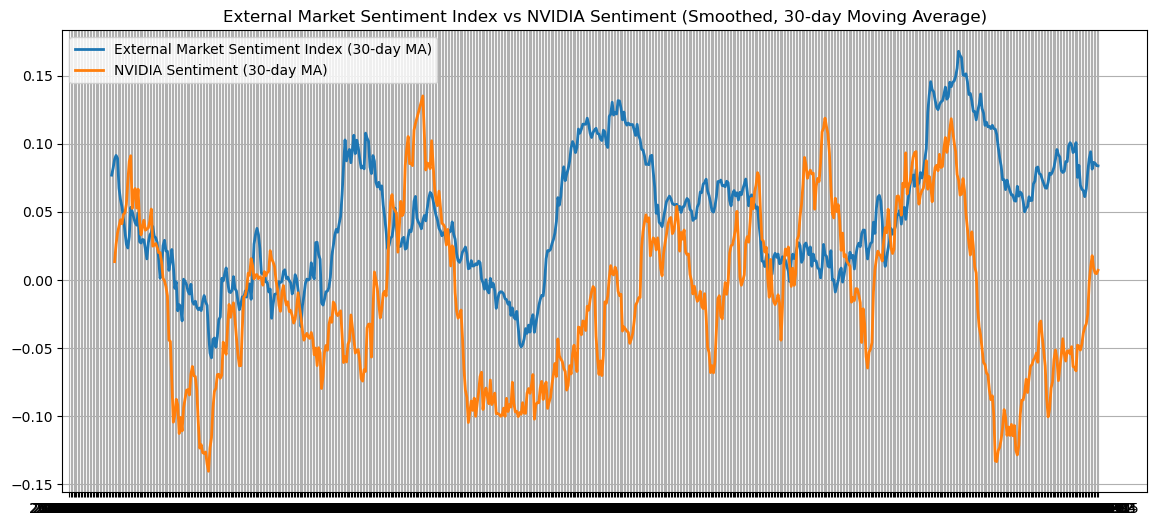

In [ ]:
external_daily["sent_score_ma"] = external_daily["sent_score"].rolling(30).mean()
nvidia_daily["sent_score_ma"] = nvidia_daily["sent_score"].rolling(30).mean()

plt.figure(figsize=(14,6))
plt.plot(external_daily["date_only"], external_daily["sent_score_ma"], label="External Market Sentiment Index (30-day MA)", linewidth=2)
plt.plot(nvidia_daily["date_only"], nvidia_daily["sent_score_ma"], label="NVIDIA Sentiment (30-day MA)", linewidth=2)

plt.legend()
plt.title("External Market Sentiment Index vs NVIDIA Sentiment (Smoothed, 30-day Moving Average)")
plt.grid(True)
plt.show()


In [ ]:
# Если дата стала индексом — вернуть её обратно в колонку
external_daily = external_daily.reset_index()
nvidia_daily = nvidia_daily.reset_index()

print(external_daily.columns)
print(nvidia_daily.columns)


Index(['level_0', 'index', 'date_only', 'belongs_to_nvidia', 'sent_neg',
       'sent_neu', 'sent_pos', 'sent_score', 'sent_score_ma'],
      dtype='object')
Index(['index', 'date_only', 'belongs_to_nvidia', 'sent_neg', 'sent_neu',
       'sent_pos', 'sent_score', 'sent_score_ma'],
      dtype='object')


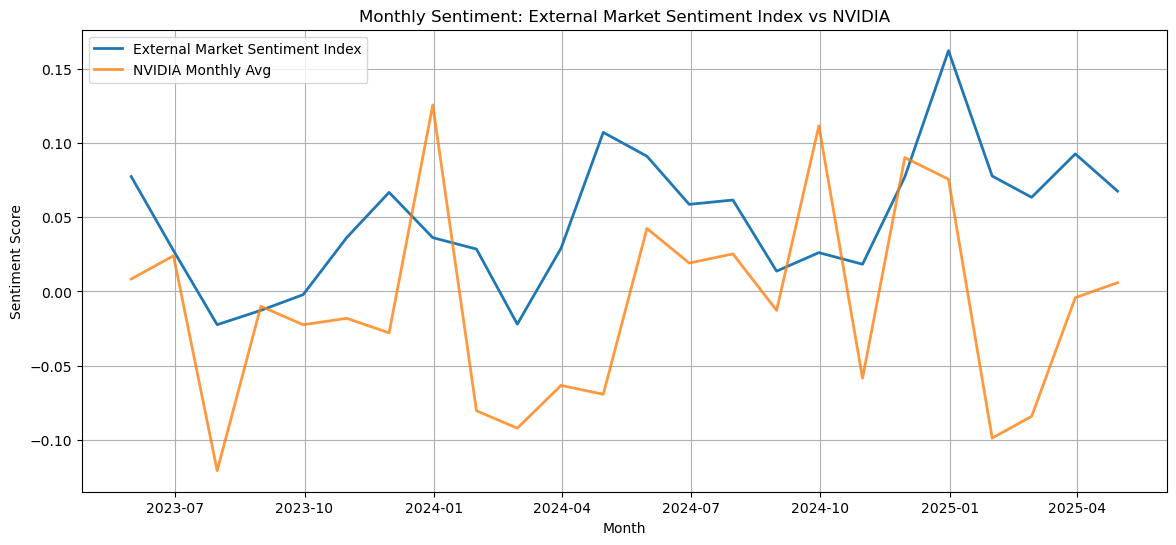

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Преобразуем даты в формат datetime
external_daily["date_only"] = pd.to_datetime(external_daily["date_only"])
nvidia_daily["date_only"] = pd.to_datetime(nvidia_daily["date_only"])

# 2. Устанавливаем дату как индекс
external_daily = external_daily.set_index("date_only")
nvidia_daily = nvidia_daily.set_index("date_only")

# 3. Делаем ежемесячную агрегацию sentiment score
external_month = external_daily["sent_score"].resample('M').mean()
nv_month = nvidia_daily["sent_score"].resample('M').mean()

# 4. Строим график
plt.figure(figsize=(14,6))
plt.plot(external_month.index, external_month, label="External Market Sentiment Index", linewidth=2)
plt.plot(nv_month.index, nv_month, label="NVIDIA Monthly Avg", linewidth=2, alpha=0.8)

plt.legend()
plt.grid(True)
plt.title("Monthly Sentiment: External Market Sentiment Index vs NVIDIA")
plt.xlabel("Month")
plt.ylabel("Sentiment Score")
plt.show()



далее просто сравниваем с ценой

In [ ]:
import pandas as pd

# Загружаем цену NVDA
df_nvda_price = pd.read_csv("nvdaclose (1) - nvda (1).csv")

# Приводим дату к нормальному формату
df_nvda_price["Date"] = pd.to_datetime(df_nvda_price["Date"])

# Оставляем только дату и цену закрытия
df_nvda_price = df_nvda_price[["Date", "Close"]]

df_nvda_price.rename(columns={"Date": "date_only", "Close": "NVDA_Close"}, inplace=True)

df_nvda_price.head()


,date_only,NVDA_Close
0,2023-05-01,28.885990
1,2023-05-02,28.186575
2,2023-05-03,27.778915
3,2023-05-04,27.539114
4,2023-05-05,28.656181


In [ ]:
# Если дата стала индексом — вернуть её обратно в колонку
external_daily = external_daily.reset_index()
nvidia_daily = nvidia_daily.reset_index()
print(external_daily.columns)
print(nvidia_daily.columns)

Index(['date_only', 'level_0', 'index', 'belongs_to_nvidia', 'sent_neg',
       'sent_neu', 'sent_pos', 'sent_score', 'sent_score_ma'],
      dtype='object')
Index(['date_only', 'index', 'belongs_to_nvidia', 'sent_neg', 'sent_neu',
       'sent_pos', 'sent_score', 'sent_score_ma'],
      dtype='object')


In [ ]:
external_daily["date_only"] = pd.to_datetime(external_daily["date_only"])
nvidia_daily["date_only"] = pd.to_datetime(nvidia_daily["date_only"])
df_nvda_price["date_only"] = pd.to_datetime(df_nvda_price["date_only"])


In [ ]:
df_merged = (
    df_nvda_price
    .merge(external_daily[["date_only", "sent_score"]].rename(columns={"sent_score": "External_Sentiment"}),
           on="date_only", how="left")
    .merge(nvidia_daily[["date_only", "sent_score"]].rename(columns={"sent_score": "NVIDIA_Sentiment"}),
           on="date_only", how="left")
)

df_merged.head()


,date_only,NVDA_Close,External_Sentiment,NVIDIA_Sentiment
0,2023-05-01,28.885990,-0.065412,-0.410031
1,2023-05-02,28.186575,-0.063044,0.019661
2,2023-05-03,27.778915,0.183244,0.091959
3,2023-05-04,27.539114,0.017111,-0.093442
4,2023-05-05,28.656181,0.233897,-0.224543


In [ ]:
df_merged = (
    df_nvda_price
    .merge(
        external_daily[["date_only", "sent_score"]]
        .rename(columns={"sent_score": "External_Sentiment"}),
        on="date_only",
        how="left"
    )
    .merge(
        nvidia_daily[["date_only", "sent_score"]]
        .rename(columns={"sent_score": "NVIDIA_Sentiment"}),
        on="date_only",
        how="left"
    )
)

df_merged.head()


,date_only,NVDA_Close,External_Sentiment,NVIDIA_Sentiment
0,2023-05-01,28.885990,-0.065412,-0.410031
1,2023-05-02,28.186575,-0.063044,0.019661
2,2023-05-03,27.778915,0.183244,0.091959
3,2023-05-04,27.539114,0.017111,-0.093442
4,2023-05-05,28.656181,0.233897,-0.224543


In [ ]:
df_merged.to_csv("NVDA_with_Sentiment.csv", index=False)
print("Слияние завершено!")


Слияние завершено!


In [ ]:
df_merged.fillna(method="ffill", inplace=True)   # переносим последнее известное значение
df_merged.fillna(0, inplace=True)                # если долго не было новостей


In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import grangercausalitytests

df = df_merged.copy()

# === 1. LOG PRICE & RETURNS ===
df["log_price"] = np.log(df["NVDA_Close"])
df["NVDA_return"] = df["NVDA_Close"].pct_change()
df = df.dropna(subset=["NVDA_return"])


# === 2. CORRELATIONS ===
def print_corr(title, cols):
    print(f"\n=== {title} ===")
    print(df[cols].corr())


print_corr("Correlation with Price",
           ["External_Sentiment", "NVIDIA_Sentiment", "NVDA_Close"])

print_corr("Correlation with Log Price",
           ["External_Sentiment", "NVIDIA_Sentiment", "log_price"])

print_corr("Correlation with Returns",
           ["External_Sentiment", "NVIDIA_Sentiment", "NVDA_return"])



# === 3. LAG CORRELATION (0–7 days) ===
lags = range(0, 8)
lag_data = []

for lag in lags:
    lag_data.append({
        "lag": lag,
        "corr_ext": df["External_Sentiment"].shift(lag).corr(df["NVDA_return"]),
        "corr_nvda": df["NVIDIA_Sentiment"].shift(lag).corr(df["NVDA_return"]),
    })

lag_df = pd.DataFrame(lag_data)
print("\n=== Lag Correlation (Sentiment → NVDA_Return) ===")
print(lag_df)



# === 4. GRANGER CAUSALITY TEST ===

def run_granger(cause, maxlag=7):
    print(f"\n==============================")
    print(f"   GRANGER TEST: {cause} → NVDA_return")
    print("==============================")

    df_gc = df[["NVDA_return", cause]].dropna()

    results = grangercausalitytests(
        df_gc,
        maxlag=maxlag,
        verbose=False
    )

    for lag in range(1, maxlag+1):
        p = results[lag][0]["ssr_ftest"][1]
        print(f"Lag {lag}: p-value = {p:.4f}")

    if any(results[lag][0]["ssr_ftest"][1] < 0.05 for lag in range(1, maxlag+1)):
        print("Conclusion: CAUSALITY DETECTED")
    else:
        print("Conclusion: NO CAUSALITY")


# External sentiment → returns
run_granger("External_Sentiment")

# NVIDIA-related sentiment → returns
run_granger("NVIDIA_Sentiment")



=== Correlation with Price ===
                    External_Sentiment  NVIDIA_Sentiment  NVDA_Close
External_Sentiment            1.000000          0.162554    0.114582
NVIDIA_Sentiment              0.162554          1.000000    0.236194
NVDA_Close                    0.114582          0.236194    1.000000

=== Correlation with Log Price ===
                    External_Sentiment  NVIDIA_Sentiment  log_price
External_Sentiment            1.000000          0.162554   0.100828
NVIDIA_Sentiment              0.162554          1.000000   0.213033
log_price                     0.100828          0.213033   1.000000

=== Correlation with Returns ===
                    External_Sentiment  NVIDIA_Sentiment  NVDA_return
External_Sentiment            1.000000          0.162554    -0.059063
NVIDIA_Sentiment              0.162554          1.000000     0.023268
NVDA_return                  -0.059063          0.023268     1.000000

=== Lag Correlation (Sentiment → NVDA_Return) ===
   lag  corr_ext  c

In [ ]:
corr = df_merged[["NVDA_Close", "External_Sentiment", "NVIDIA_Sentiment"]].corr()
corr


,NVDA_Close,External_Sentiment,NVIDIA_Sentiment
NVDA_Close,1.000000,0.117469,0.240766
External_Sentiment,0.117469,1.000000,0.166163
NVIDIA_Sentiment,0.240766,0.166163,1.000000


In [ ]:
df_merged["roll_corr_external"] = (
    df_merged["NVDA_Close"]
    .rolling(30)
    .corr(df_merged["External_Sentiment"])
)

df_merged["roll_corr_nvidia"] = (
    df_merged["NVDA_Close"]
    .rolling(30)
    .corr(df_merged["NVIDIA_Sentiment"])
)


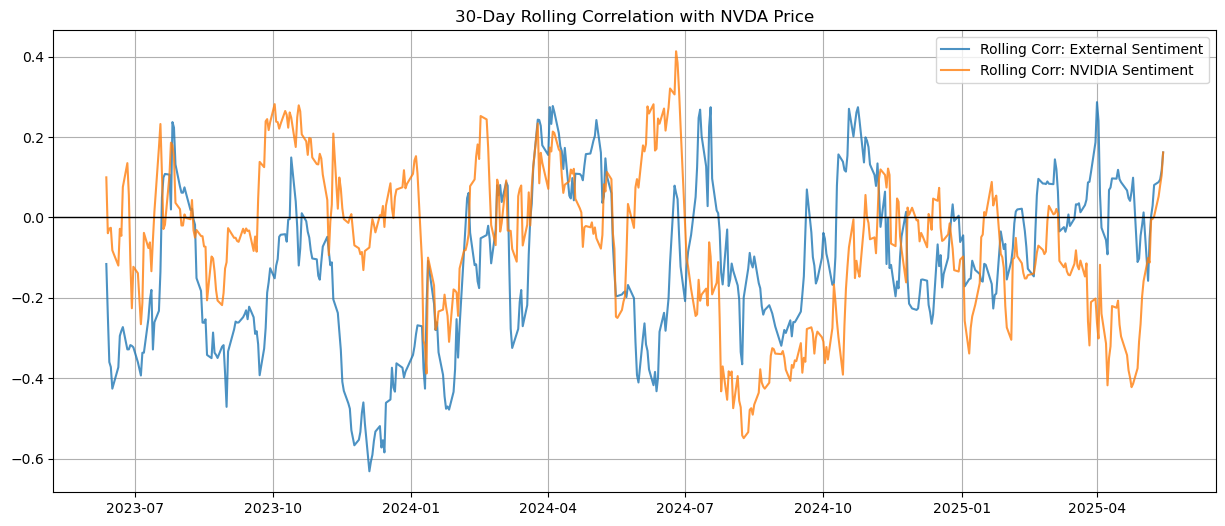

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(df_merged["date_only"], df_merged["roll_corr_external"], label="Rolling Corr: External Sentiment", alpha=0.8)
plt.plot(df_merged["date_only"], df_merged["roll_corr_nvidia"], label="Rolling Corr: NVIDIA Sentiment", alpha=0.8)
plt.axhline(0, color="black", linewidth=1)
plt.legend()
plt.title("30-Day Rolling Correlation with NVDA Price")
plt.grid(True)
plt.show()


In [ ]:
import numpy as np

def cross_corr(x, y, lag=10):
    lags = range(-lag, lag+1)
    values = []
    for l in lags:
        if l < 0:
            values.append(np.corrcoef(x[:l], y[-l:])[0,1])
        else:
            values.append(np.corrcoef(x[l:], y[:-l] if l!=0 else y)[0,1])
    return lags, values


In [ ]:
plt.figure(figsize=(12,5))
plt.stem(lags, cvals)
plt.title("Cross-Correlation: External Sentiment → NVDA Price Returns")
plt.xlabel("Lag (days)")
plt.ylabel("Correlation")
plt.grid(True)
plt.show()



NameError: name 'cvals' is not defined

<Figure size 1200x500 with 0 Axes>

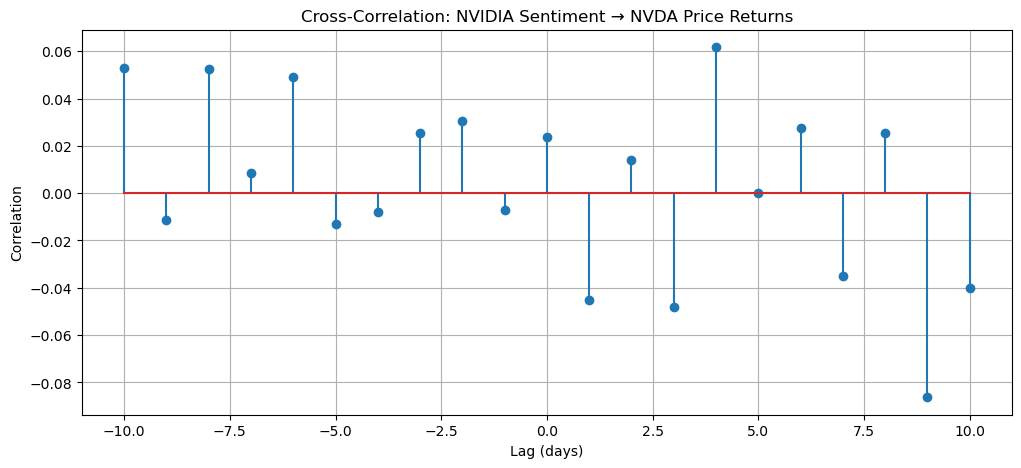

In [ ]:
plt.figure(figsize=(12,5))
plt.stem(lags2, cvals2)
plt.title("Cross-Correlation: NVIDIA Sentiment → NVDA Price Returns")
plt.xlabel("Lag (days)")
plt.ylabel("Correlation")
plt.grid(True)
plt.show()



гранжер тест

In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests

df_gc = df_merged[["NVDA_Close", "External_Sentiment", "NVIDIA_Sentiment"]].dropna()


In [ ]:
print("External Sentiment → NVDA Price")
grangercausalitytests(df_gc[["NVDA_Close", "External_Sentiment"]], maxlag=5)


External Sentiment → NVDA Price

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0099  , p=0.9208  , df_denom=571, df_num=1
ssr based chi2 test:   chi2=0.0099  , p=0.9206  , df=1
likelihood ratio test: chi2=0.0099  , p=0.9206  , df=1
parameter F test:         F=0.0099  , p=0.9208  , df_denom=571, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.1419  , p=0.8677  , df_denom=568, df_num=2
ssr based chi2 test:   chi2=0.2863  , p=0.8666  , df=2
likelihood ratio test: chi2=0.2862  , p=0.8666  , df=2
parameter F test:         F=0.1419  , p=0.8677  , df_denom=568, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.1088  , p=0.9550  , df_denom=565, df_num=3
ssr based chi2 test:   chi2=0.3304  , p=0.9542  , df=3
likelihood ratio test: chi2=0.3303  , p=0.9542  , df=3
parameter F test:         F=0.1088  , p=0.9550  , df_denom=565, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test

{np.int64(1): ({'ssr_ftest': (np.float64(0.009888763344810057),
    np.float64(0.9208220309100005),
    np.float64(571.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.009940718318600652),
    np.float64(0.9205799988768657),
    np.int64(1)),
   'lrtest': (np.float64(0.009940632240613922),
    np.float64(0.9205803415938539),
    np.int64(1)),
   'params_ftest': (np.float64(0.009888763344684835),
    np.float64(0.9208220309107593),
    np.float64(571.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(0.14190667127062248),
    np.float64(0.8677329875071469),
    np.float64(568.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(0.2863116994298122),
    np.float64(0.8666189960467638),
    np.int64(2)),
   'lrtest': (np.float64(0.28624019236758613),
    np.float64(0.8666499812899148),
    np.int64(2)),
   'params_ftest': (np.float64(0.14190667127063009),
    np.float64(0.8677329875071469),
    np.float64(568.0),
    2.0)},
   array([[0., 0., 1., 0., 

In [ ]:
print("NVIDIA Sentiment → NVDA Price")
grangercausalitytests(df_gc[["NVDA_Close", "NVIDIA_Sentiment"]], maxlag=5)


NVIDIA Sentiment → NVDA Price

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.4010  , p=0.5268  , df_denom=571, df_num=1
ssr based chi2 test:   chi2=0.4031  , p=0.5255  , df=1
likelihood ratio test: chi2=0.4030  , p=0.5255  , df=1
parameter F test:         F=0.4010  , p=0.5268  , df_denom=571, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.7148  , p=0.4897  , df_denom=568, df_num=2
ssr based chi2 test:   chi2=1.4422  , p=0.4862  , df=2
likelihood ratio test: chi2=1.4403  , p=0.4867  , df=2
parameter F test:         F=0.7148  , p=0.4897  , df_denom=568, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.8336  , p=0.4758  , df_denom=565, df_num=3
ssr based chi2 test:   chi2=2.5317  , p=0.4696  , df=3
likelihood ratio test: chi2=2.5261  , p=0.4706  , df=3
parameter F test:         F=0.8336  , p=0.4758  , df_denom=565, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test: 

{np.int64(1): ({'ssr_ftest': (np.float64(0.40104168233918924),
    np.float64(0.5268053324182373),
    np.float64(571.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.40314873145830926),
    np.float64(0.5254675848028334),
    np.int64(1)),
   'lrtest': (np.float64(0.4030072220166403),
    np.float64(0.5255402746373187),
    np.int64(1)),
   'params_ftest': (np.float64(0.4010416823387329),
    np.float64(0.5268053324184663),
    np.float64(571.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(0.7147877155699373),
    np.float64(0.48973555737954133),
    np.float64(568.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(1.442159721906951),
    np.float64(0.4862269149034413),
    np.int64(2)),
   'lrtest': (np.float64(1.4403479055990829),
    np.float64(0.4866675914063959),
    np.int64(2)),
   'params_ftest': (np.float64(0.7147877155699571),
    np.float64(0.4897355573795258),
    np.float64(568.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
    

In [ ]:
print("NVDA Price → External Sentiment")
grangercausalitytests(df_gc[["External_Sentiment", "NVDA_Close"]], maxlag=5)


NVDA Price → External Sentiment

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=5.1156  , p=0.0241  , df_denom=571, df_num=1
ssr based chi2 test:   chi2=5.1425  , p=0.0233  , df=1
likelihood ratio test: chi2=5.1196  , p=0.0237  , df=1
parameter F test:         F=5.1156  , p=0.0241  , df_denom=571, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=4.7086  , p=0.0094  , df_denom=568, df_num=2
ssr based chi2 test:   chi2=9.5001  , p=0.0087  , df=2
likelihood ratio test: chi2=9.4222  , p=0.0090  , df=2
parameter F test:         F=4.7086  , p=0.0094  , df_denom=568, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=4.2970  , p=0.0052  , df_denom=565, df_num=3
ssr based chi2 test:   chi2=13.0508 , p=0.0045  , df=3
likelihood ratio test: chi2=12.9041 , p=0.0048  , df=3
parameter F test:         F=4.2970  , p=0.0052  , df_denom=565, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test

{np.int64(1): ({'ssr_ftest': (np.float64(5.115625683756573),
    np.float64(0.024086519372104653),
    np.float64(571.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(5.142502876490846),
    np.float64(0.02334696551611091),
    np.int64(1)),
   'lrtest': (np.float64(5.1196035391290025),
    np.float64(0.02365702087505391),
    np.int64(1)),
   'params_ftest': (np.float64(5.115625683756638),
    np.float64(0.024086519372103498),
    np.float64(571.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(4.708597962172886),
    np.float64(0.00937235538995601),
    np.float64(568.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(9.500093775792479),
    np.float64(0.008651289552843774),
    np.int64(2)),
   'lrtest': (np.float64(9.422199825885855),
    np.float64(0.00899487855605707),
    np.int64(2)),
   'params_ftest': (np.float64(4.708597962173606),
    np.float64(0.009372355389949127),
    np.float64(568.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
 

In [ ]:
print("NVDA Price → Nvidia Sentiment")
grangercausalitytests(df_gc[["NVIDIA_Sentiment", "NVDA_Close"]], maxlag=5)


NVDA Price → Nvidia Sentiment

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=22.9720 , p=0.0000  , df_denom=571, df_num=1
ssr based chi2 test:   chi2=23.0927 , p=0.0000  , df=1
likelihood ratio test: chi2=22.6403 , p=0.0000  , df=1
parameter F test:         F=22.9720 , p=0.0000  , df_denom=571, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=8.9049  , p=0.0002  , df_denom=568, df_num=2
ssr based chi2 test:   chi2=17.9666 , p=0.0001  , df=2
likelihood ratio test: chi2=17.6907 , p=0.0001  , df=2
parameter F test:         F=8.9049  , p=0.0002  , df_denom=568, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=5.6413  , p=0.0008  , df_denom=565, df_num=3
ssr based chi2 test:   chi2=17.1337 , p=0.0007  , df=3
likelihood ratio test: chi2=16.8821 , p=0.0007  , df=3
parameter F test:         F=5.6413  , p=0.0008  , df_denom=565, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test: 

{np.int64(1): ({'ssr_ftest': (np.float64(22.971998805518044),
    np.float64(2.098935521576477e-06),
    np.float64(571.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(23.09269231938241),
    np.float64(1.5437631213194385e-06),
    np.int64(1)),
   'lrtest': (np.float64(22.64026394050029),
    np.float64(1.9534758694537492e-06),
    np.int64(1)),
   'params_ftest': (np.float64(22.97199880551823),
    np.float64(2.0989355215763127e-06),
    np.float64(571.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(8.90490262889371),
    np.float64(0.00015561180681766194),
    np.float64(568.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(17.966581712521467),
    np.float64(0.0001254892003277282),
    np.int64(2)),
   'lrtest': (np.float64(17.690660908450127),
    np.float64(0.00014405282948794806),
    np.int64(2)),
   'params_ftest': (np.float64(8.904902628894327),
    np.float64(0.00015561180681756545),
    np.float64(568.0),
    2.0)},
   array([[0.,

теперь берттопик      

In [ ]:
!pip install bertopic


In [ ]:
!pip install sentence-transformers
!pip install umap-learn
!pip install hdbscan


In [ ]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
import pandas as pd


In [ ]:
df = pd.read_csv("ALL_3_finbert_sentiment.csv")

# Удаляем пустые строки текста
df = df.dropna(subset=["clean_text"])

# Приводим дату
df["date_only"] = pd.to_datetime(df["date_only"])


In [ ]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")


In [ ]:
topic_model = BERTopic(
    embedding_model=embedding_model,
    top_n_words=10,
    verbose=True
)

topics, probs = topic_model.fit_transform(df["clean_text"])


2025-12-15 14:00:33,596 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/1090 [00:00<?, ?it/s]

2025-12-15 14:02:30,861 - BERTopic - Embedding - Completed ✓
2025-12-15 14:02:30,862 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-15 14:03:01,210 - BERTopic - Dimensionality - Completed ✓
2025-12-15 14:03:01,212 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-15 14:03:04,342 - BERTopic - Cluster - Completed ✓
2025-12-15 14:03:04,352 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-15 14:03:05,009 - BERTopic - Representation - Completed ✓


In [ ]:
topic_info = topic_model.get_topic_info()
topic_info.head(15)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,13190,-1_ai_and_nvidia_to,"[ai, and, nvidia, to, the, in, for, 500, as, b...","[Stock Market Today Dow Jones Futures, Nasdaq,..."
1,0,659,0_nvda_corp_nvidia_shares,"[nvda, corp, nvidia, shares, corporation, trad...",[Nvidia NASDAQ NVDA has been one of the best-p...
2,1,530,1_artificial_intelligence_ai_these,"[artificial, intelligence, ai, these, stocks, ...",[Artificial intelligence AI is the hottest tre...
3,2,458,2_nvidia_ai_chips_artificial,"[nvidia, ai, chips, artificial, intelligence, ...",[Nvidia is expected to continue to see strong ...
4,3,298,3_etfs_vanguard_etf_leveraged,"[etfs, vanguard, etf, leveraged, exchange, fun...",[Investment management firm Vanguard offers lo...
5,4,298,4_jones_dow_100_news,"[jones, dow, 100, news, nasdaq, 500, preview, ...","[NASDAQ 100, Dow Jones, S P 500 News Market Ey..."
6,5,296,5_tech_stocks_technology_these,"[tech, stocks, technology, these, sector, barg...",[These top tech stocks are up big this year bu...
7,6,289,6_chipmaker_chip_flying_chipmakers,"[chipmaker, chip, flying, chipmakers, cyclical...",[This high-flying chipmaker has a bright futur...
8,7,289,7_apple_iphone_aapl_mac,"[apple, iphone, aapl, mac, iphones, trillion, ...","[Apple Stock iPhone Sales Weak In China, U.S. ..."
9,8,261,8_prnewswire_newswire_globe_2022,"[prnewswire, newswire, globe, 2022, global, di...","[DUBLIN, Aug. 16, 2022 PRNewswire -- The Globa..."


In [ ]:
topic_info.to_csv("topic.csv")

In [ ]:
# Keywords for AI-sector topics
ai_keywords = [
    "ai", "artificial", "intelligence", "machine learning", "ml",
    "deep learning", "neural", "llm", "openai", "chatgpt", "deepseek",
    "compute", "computing", "datacenter", "data center",
    "semiconductor", "chip", "chips", "gpus", "gpu demand"
]

# Keywords for NVIDIA-specific topics
nvda_keywords = [
    "nvidia", "nvda", "geforce", "h100", "h200", "cuda",
    "rtx", "gtc", "tensor core", "dgx", "jensen", "huang"
]


In [ ]:
def topic_matches(name, keywords):
    name_lower = str(name).lower()
    for kw in keywords:
        if kw in name_lower:
            return True
    return False

topic_info["is_ai_topic"] = topic_info["Name"].apply(
    lambda x: topic_matches(x, ai_keywords)
)

topic_info["is_nvda_topic"] = topic_info["Name"].apply(
    lambda x: topic_matches(x, nvda_keywords)
)


In [ ]:
ai_topic_ids = topic_info[topic_info["is_ai_topic"] == True]["Topic"].tolist()
nvda_topic_ids = topic_info[topic_info["is_nvda_topic"] == True]["Topic"].tolist()

print("AI topics:", ai_topic_ids)
print("NVDA topics:", nvda_topic_ids)


AI topics: [-1, 1, 2, 6, 11, 14, 18, 20, 22, 29, 36, 42, 47, 52, 55, 57, 67, 78, 94, 97, 98, 109, 113, 131, 136, 145, 146, 157, 178, 191, 199, 204, 220, 236, 237, 249, 278, 284, 288, 290, 302, 303, 306, 308, 319, 327, 341, 365, 375, 386, 389, 407, 411, 415, 428, 429, 430, 437, 453, 455, 461, 464]
NVDA topics: [-1, 0, 2, 13, 33, 34, 49, 59, 118, 195, 205]


In [ ]:
import pandas as pd

# --- AI Topics (detailed) ---
ai_topics_df = topic_info[ topic_info["Topic"].isin(ai_topic_ids) ]

# вывод на экран
display(ai_topics_df)

# сохранение в CSV
ai_topics_df.to_csv("AI_topics_detailed.csv", index=False)


# --- NVIDIA Topics (detailed) ---
nvda_topics_df = topic_info[ topic_info["Topic"].isin(nvda_topic_ids) ]

# вывод на экран
display(nvda_topics_df)

# сохранение в CSV
nvda_topics_df.to_csv("NVDA_topics_detailed.csv", index=False)


,Topic,Count,Name,Representation,Representative_Docs,is_ai_topic,is_nvda_topic
0,-1,13190,-1_ai_and_nvidia_to,"[ai, and, nvidia, to, the, in, for, 500, as, b...","[Stock Market Today Dow Jones Futures, Nasdaq,...",True,True
2,1,530,1_artificial_intelligence_ai_these,"[artificial, intelligence, ai, these, stocks, ...",[Artificial intelligence AI is the hottest tre...,True,False
3,2,458,2_nvidia_ai_chips_artificial,"[nvidia, ai, chips, artificial, intelligence, ...",[Nvidia is expected to continue to see strong ...,True,True
7,6,289,6_chipmaker_chip_flying_chipmakers,"[chipmaker, chip, flying, chipmakers, cyclical...",[This high-flying chipmaker has a bright futur...,True,False
12,11,199,11_quantum_computing_ionq_rigetti,"[quantum, computing, ionq, rigetti, rgti, will...",[Shares of quantum computing stocks like D-Wav...,True,False
...,...,...,...,...,...,...,...
438,437,12,437_titan_tailwinds_heights_drive,"[titan, tailwinds, heights, drive, secular, he...",[A rebounding economy and strong growth should...,True,False
454,453,11,453_jerome_powell_chair_hole,"[jerome, powell, chair, hole, jackson, reserve...",[Monday market open What do you get when you c...,True,False
456,455,11,455_bargains_busts_hesitation_debris,"[bargains, busts, hesitation, debris, chili, t...",[You can be bold enough to buy a discounted pr...,True,False
462,461,11,461_internet_underpin_streamlining_rail,"[internet, underpin, streamlining, rail, diver...",[Our theme of Internet Infrastructure Stocks -...,True,False


,Topic,Count,Name,Representation,Representative_Docs,is_ai_topic,is_nvda_topic
0,-1,13190,-1_ai_and_nvidia_to,"[ai, and, nvidia, to, the, in, for, 500, as, b...","[Stock Market Today Dow Jones Futures, Nasdaq,...",True,True
1,0,659,0_nvda_corp_nvidia_shares,"[nvda, corp, nvidia, shares, corporation, trad...",[Nvidia NASDAQ NVDA has been one of the best-p...,False,True
3,2,458,2_nvidia_ai_chips_artificial,"[nvidia, ai, chips, artificial, intelligence, ...",[Nvidia is expected to continue to see strong ...,True,True
14,13,188,13_quarter_nvda_revenue_reported,"[quarter, nvda, revenue, reported, results, qu...",[NVIDIA Corporation NVDA is set to release ear...,False,True
34,33,119,33_nvidia_stock_should_investors,"[nvidia, stock, should, investors, price, buy,...",[Recent market headwinds are giving Nvidia inv...,False,True
35,34,118,34_nvidia_could_growth_bumps,"[nvidia, could, growth, bumps, segment, be, ad...",[Nvidia s growth potential might be in the han...,False,True
50,49,95,49_dgx_omniverse_globe_newswire,"[dgx, omniverse, globe, newswire, announced, c...","[SANTA CLARA, Calif., March 21, 2023 GLOBE NEW...",False,True
60,59,84,59_huang_jensen_ceo_denny,"[huang, jensen, ceo, denny, his, insider, he, ...","[Jensen Huang has been selling since June., Wh...",False,True
119,118,49,118_blackwell_rubin_huang_tracker,"[blackwell, rubin, huang, tracker, ultra, caug...",[The Blackwell chip will be one of Nvidia s mo...,False,True
196,195,30,195_huang_jensen_ceo_he,"[huang, jensen, ceo, he, his, individuals, dea...",[Nvidia CEO Jensen Huang anticipates that the ...,False,True


In [ ]:
import pandas as pd


pd.DataFrame({"ai_topic_ids": ai_topic_ids}).to_csv("ai_topics.csv", index=False)
pd.DataFrame({"nvda_topic_ids": nvda_topic_ids}).to_csv("nvda_topics.csv", index=False)
with open("ai_topics.txt", "w") as f:
    f.write(",".join(map(str, ai_topic_ids)))

with open("nvda_topics.txt", "w") as f:
    f.write(",".join(map(str, nvda_topic_ids)))


In [ ]:
ai_topic_ids_final = [
    0, 7, 11, 13, 18, 26, 29, 33, 47, 54, 66,
    107, 113, 121, 152, 167, 228, 263, 273,
    285, 352, 361, 365, 424
]
nvda_topic_ids_final = [
    2, 16, 21, 35, 39, 60, 62, 73, 115, 203, 278, 292
]


In [ ]:
topic_info.columns


Index(['Topic', 'Count', 'Name', 'Representation', 'Representative_Docs',
       'is_ai_topic', 'is_nvda_topic'],
      dtype='object')

In [ ]:
df.columns

Index(['Title', 'Date', 'belongs_to_nvidia', 'date', 'date_only', 'clean_text',
       'sentiment_label', 'sent_neg', 'sent_neu', 'sent_pos'],
      dtype='object')

In [ ]:
# Add BERTopic results to df
df["Topic"] = topics

# Create AI/NVDA labels
df["is_ai_topic"] = df["Topic"].isin(ai_topic_ids_final)
df["is_nvda_topic"] = df["Topic"].isin(nvda_topic_ids_final)



In [ ]:
df.columns

Index(['Title', 'Date', 'belongs_to_nvidia', 'date', 'date_only', 'clean_text',
       'sentiment_label', 'sent_neg', 'sent_neu', 'sent_pos', 'Topic',
       'is_ai_topic', 'is_nvda_topic'],
      dtype='object')

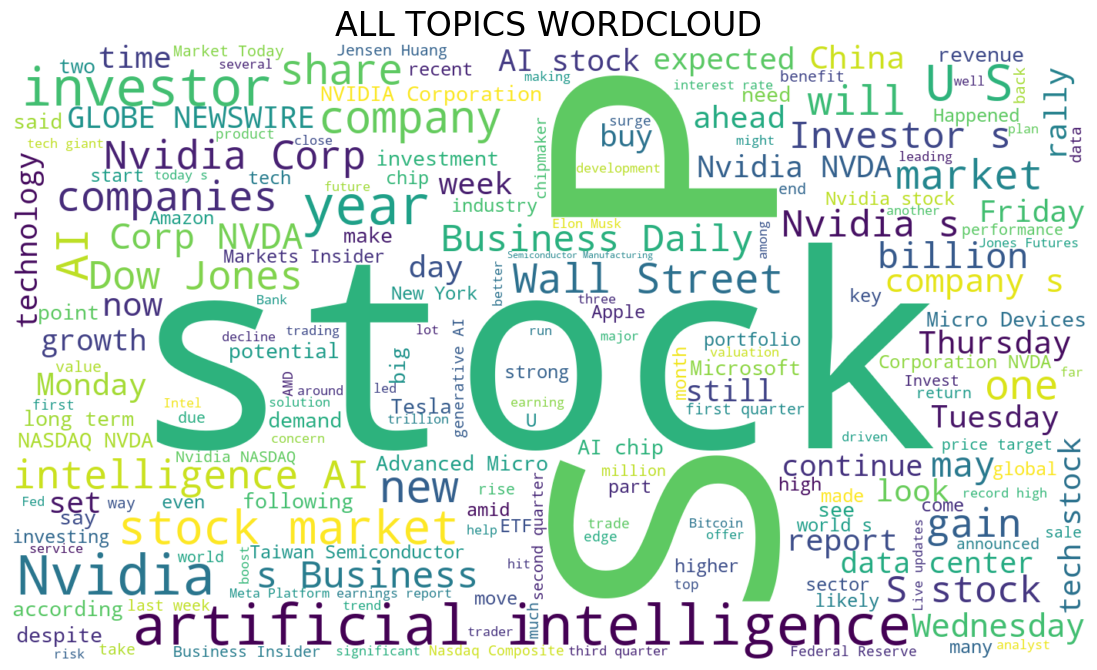

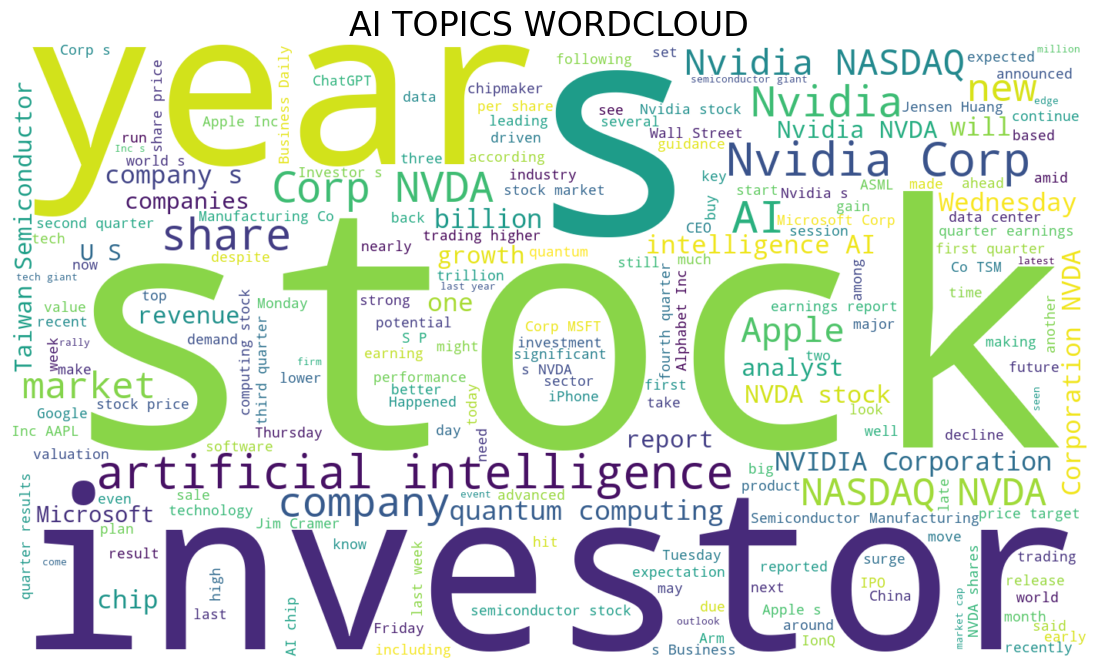

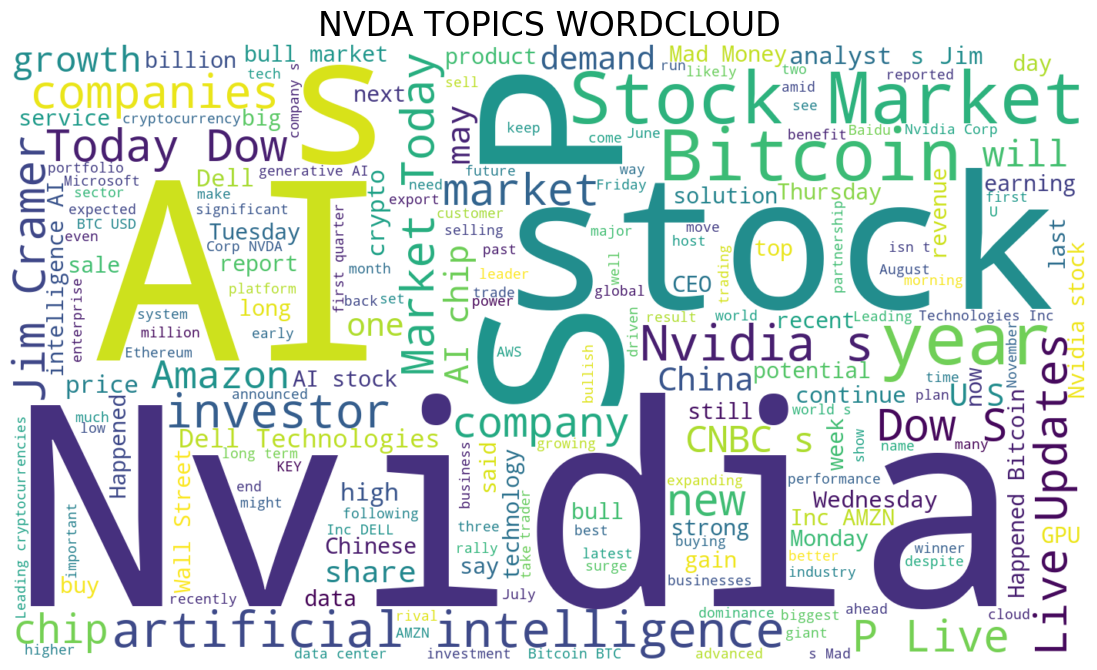

In [ ]:
# -------------------------------------------------
# INSTALL (если нужно)
# -------------------------------------------------
!pip install wordcloud matplotlib pandas

# -------------------------------------------------
# IMPORTS
# -------------------------------------------------
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# -------------------------------------------------
# ФИНАЛЬНЫЕ СПИСКИ ТОПИКОВ
# -------------------------------------------------
ai_topic_ids_final = [
    0, 7, 11, 13, 18, 26, 29, 33, 47, 54, 66,
    107, 113, 121, 152, 167, 228, 263, 273,
    285, 352, 361, 365, 424
]

nvda_topic_ids_final = [
    2, 16, 21, 35, 39, 60, 62, 73, 115, 203, 278, 292
]

# -------------------------------------------------
# CREATE LABELS IN THE DATAFRAME
# -------------------------------------------------
df["is_ai_topic"] = df["Topic"].isin(ai_topic_ids_final)
df["is_nvda_topic"] = df["Topic"].isin(nvda_topic_ids_final)

# -------------------------------------------------
# WORDCLOUD FUNCTION
# -------------------------------------------------
def generate_wordcloud(text, title):
    wc = WordCloud(width=1400, height=800, background_color="white").generate(text)

    plt.figure(figsize=(14,8))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=24)
    plt.show()

# ALL TOPICS WORDCLOUD
all_text = " ".join(df["clean_text"].astype(str))
generate_wordcloud(all_text, "ALL TOPICS WORDCLOUD")

# AI TOPICS WORDCLOUD
ai_df = df[df["is_ai_topic"] == True]
ai_text = " ".join(ai_df["clean_text"].astype(str))
generate_wordcloud(ai_text, "AI TOPICS WORDCLOUD")

# NVDA TOPICS WORDCLOUD
nvda_df = df[df["is_nvda_topic"] == True]
nvda_text = " ".join(nvda_df["clean_text"].astype(str))
generate_wordcloud(nvda_text, "NVDA TOPICS WORDCLOUD")


In [ ]:
import pandas as pd

# --- Ensure date format ---
df["date_only"] = pd.to_datetime(df["date_only"], errors="coerce")

# --- Create Daily AI Hype Index ---
ai_hype = df.groupby("date_only")["is_ai_topic"].sum()

# --- Create Daily NVDA Hype Index ---
nvda_hype = df.groupby("date_only")["is_nvda_topic"].sum()

# --- Combine into one dataframe ---
hype_df = pd.concat([ai_hype, nvda_hype], axis=1)
hype_df.columns = ["AI_Hype", "NVDA_Hype"]

# --- Fill missing days with 0 (important for time series) ---
hype_df = hype_df.asfreq("D", fill_value=0)

# --- Standardize (Z-score) ---
hype_df = (hype_df - hype_df.mean()) / hype_df.std()

hype_df.head()


,AI_Hype,NVDA_Hype
date_only,,
2023-05-01,0.475708,0.561527
2023-05-02,-0.846535,-0.495641
2023-05-03,-0.846535,0.032943
2023-05-04,-1.177096,1.090110
2023-05-05,-0.846535,-1.024224


📌 Объяснение Шага 1
Строка	Что делает
groupby("date_only")["is_ai_topic"].sum()	считает кол-во AI новостей за каждый день
asfreq("D", fill_value=0)	делает временной ряд ежедневным, заполняя пропуски
z-score	делает индекс сопоставимым во времени

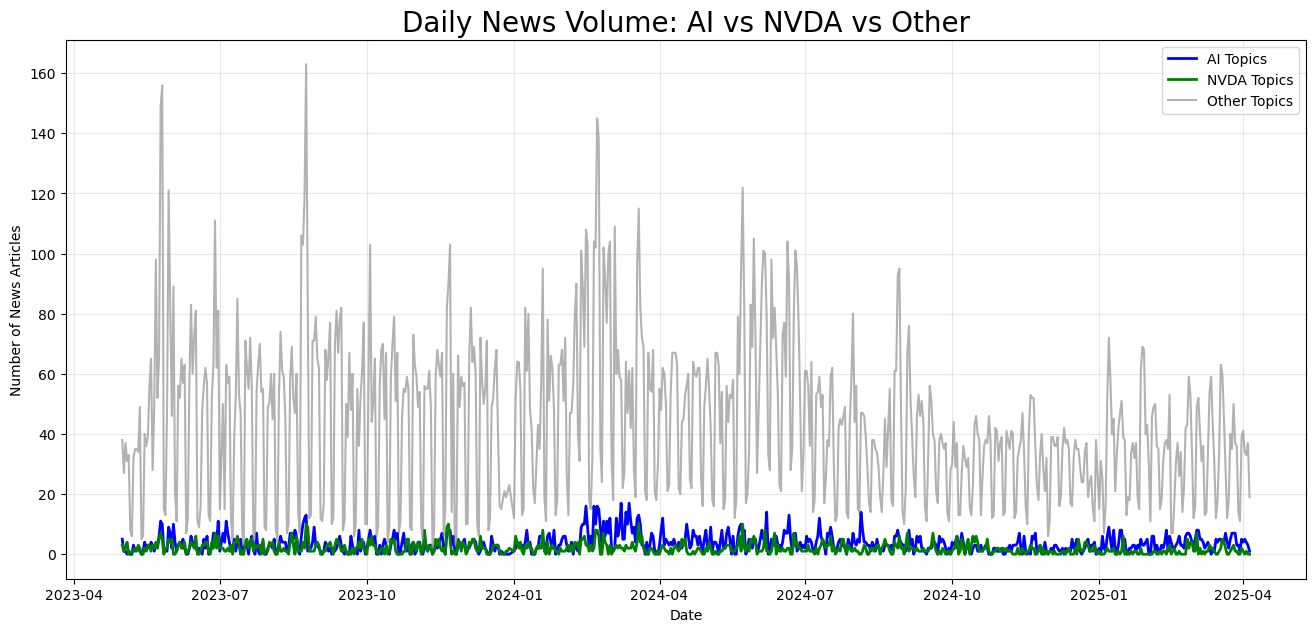

In [ ]:
# -------------------------------------------------
# 1. ПОДГОТОВКА
# -------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt

# Флаги топиков
df["is_ai_topic"] = df["Topic"].isin(ai_topic_ids_final)
df["is_nvda_topic"] = df["Topic"].isin(nvda_topic_ids_final)

# OTHER: ни AI, ни NVDA
df["is_other_topic"] = (~df["is_ai_topic"]) & (~df["is_nvda_topic"])

# Убедимся, что дата в формате datetime
df["date_only"] = pd.to_datetime(df["date_only"])


# -------------------------------------------------
# 2. ГРУППИРОВКА ПО ДНЯМ
# -------------------------------------------------

daily_counts = df.groupby("date_only").agg({
    "is_ai_topic": "sum",
    "is_nvda_topic": "sum",
    "is_other_topic": "sum"
}).rename(columns={
    "is_ai_topic": "AI_news",
    "is_nvda_topic": "NVDA_news",
    "is_other_topic": "Other_news"
})


# -------------------------------------------------
# 3. ГРАФИК
# -------------------------------------------------

plt.figure(figsize=(16,7))

plt.plot(daily_counts.index, daily_counts["AI_news"], label="AI Topics", color="blue", linewidth=2)
plt.plot(daily_counts.index, daily_counts["NVDA_news"], label="NVDA Topics", color="green", linewidth=2)
plt.plot(daily_counts.index, daily_counts["Other_news"], label="Other Topics", color="gray", linewidth=1.5, alpha=0.6)

plt.title("Daily News Volume: AI vs NVDA vs Other", fontsize=20)
plt.ylabel("Number of News Articles")
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
import pandas as pd

# Загружаем цену NVDA
df_nvda_price = pd.read_csv("nvdaclose (1) - nvda (1).csv")

# Приводим дату к нормальному формату
df_nvda_price["Date"] = pd.to_datetime(df_nvda_price["Date"])

# Оставляем только дату и цену закрытия
df_nvda_price = df_nvda_price[["Date", "Close"]]

df_nvda_price.rename(columns={"Date": "date_only", "Close": "NVDA_Close"}, inplace=True)

df_nvda_price.head()

,date_only,NVDA_Close
0,2023-05-01,28.885990
1,2023-05-02,28.186575
2,2023-05-03,27.778915
3,2023-05-04,27.539114
4,2023-05-05,28.656181


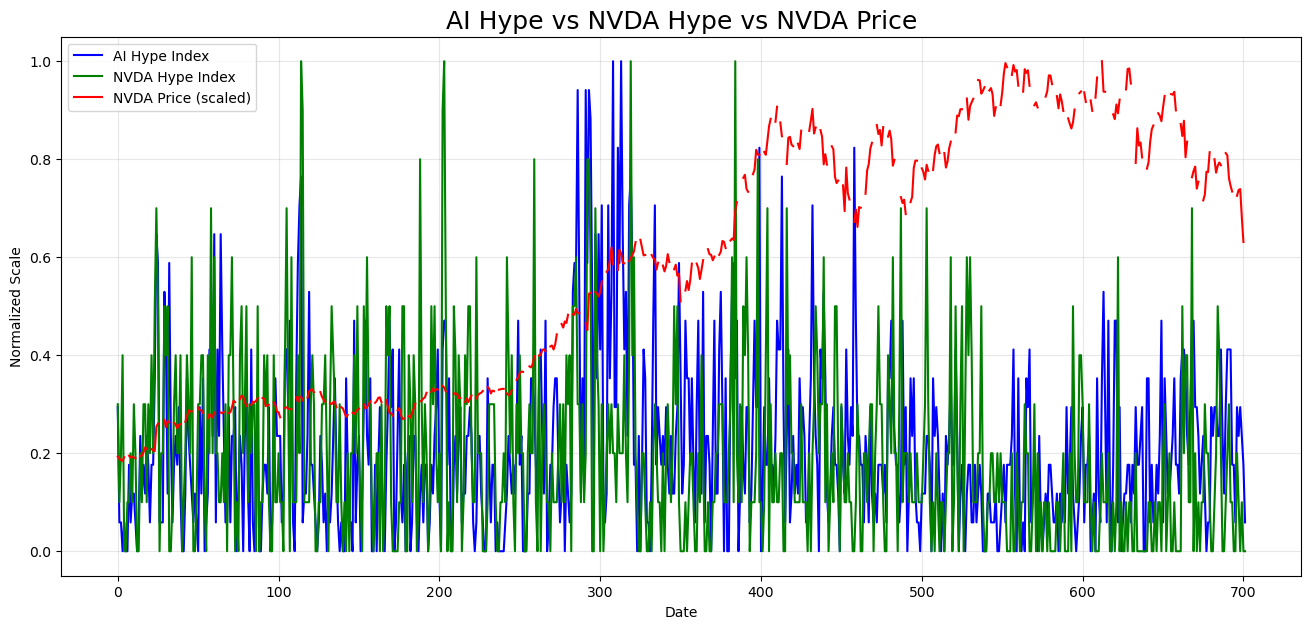

In [ ]:
# -------------------------------------------------
# 1. Создаём нормированные индексы
# -------------------------------------------------

daily = daily_counts.copy()

# Нормализация (0–1)
daily["AI_norm"] = daily["AI_news"] / daily["AI_news"].max()
daily["NVDA_norm"] = daily["NVDA_news"] / daily["NVDA_news"].max()
daily["Other_norm"] = daily["Other_news"] / daily["Other_news"].max()

# Доля AI и NVDA новостей в день
daily["AI_share"] = daily["AI_news"] / (
    daily["AI_news"] + daily["NVDA_news"] + daily["Other_news"]
)

daily["NVDA_share"] = daily["NVDA_news"] / (
    daily["AI_news"] + daily["NVDA_news"] + daily["Other_news"]
)


# -------------------------------------------------
# 2. Объединяем с ценой NVDA
# -------------------------------------------------

df_nvda_price["date_only"] = pd.to_datetime(df_nvda_price["date_only"])

merged = pd.merge(daily, df_nvda_price, on="date_only", how="left")

# Доходность NVDA
merged["NVDA_return"] = merged["NVDA_Close"].pct_change()


# -------------------------------------------------
# 3. Строим график
# -------------------------------------------------

plt.figure(figsize=(16,7))

plt.plot(merged.index, merged["AI_norm"], label="AI Hype Index", color="blue")
plt.plot(merged.index, merged["NVDA_norm"], label="NVDA Hype Index", color="green")
plt.plot(merged.index, merged["NVDA_Close"] / merged["NVDA_Close"].max(),
         label="NVDA Price (scaled)", color="red")

plt.title("AI Hype vs NVDA Hype vs NVDA Price", fontsize=18)
plt.xlabel("Date")
plt.ylabel("Normalized Scale")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


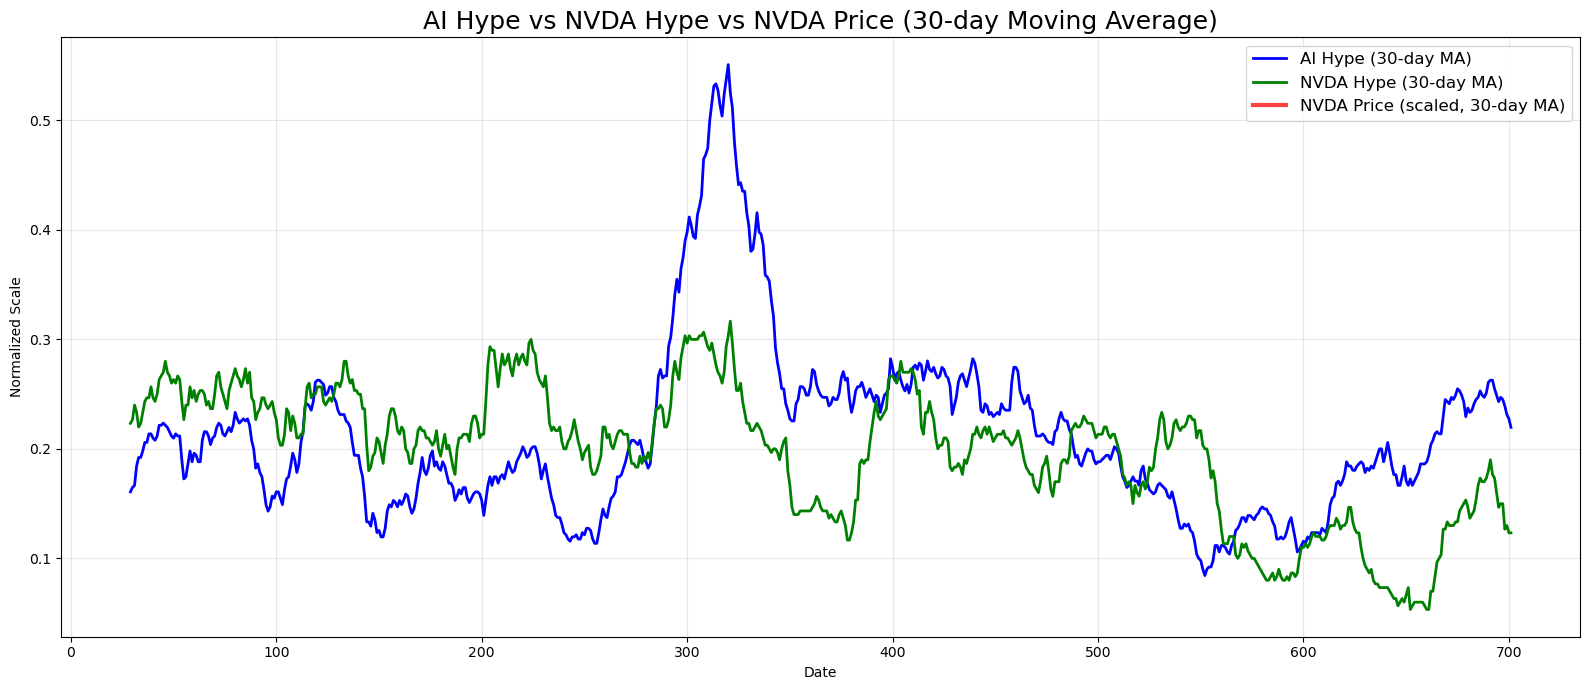

In [ ]:
# -------------------------------------------------------------
# AI vs NVDA Hype vs NVDA Price — 30-day Moving Average Plot
# -------------------------------------------------------------

import matplotlib.pyplot as plt

# 1. Moving averages for hype indexes
merged["AI_ma30"] = merged["AI_norm"].rolling(30).mean()
merged["NVDA_ma30"] = merged["NVDA_norm"].rolling(30).mean()

# 2. Scale NVDA price to 0–1 range and smooth it
merged["NVDA_price_scaled"] = merged["NVDA_Close"] / merged["NVDA_Close"].max()
merged["NVDA_price_ma30"] = merged["NVDA_price_scaled"].rolling(30).mean()

# 3. Plot
plt.figure(figsize=(16,7))

plt.plot(merged.index, merged["AI_ma30"],
         label="AI Hype (30-day MA)", color="blue", linewidth=2)

plt.plot(merged.index, merged["NVDA_ma30"],
         label="NVDA Hype (30-day MA)", color="green", linewidth=2)

plt.plot(merged.index, merged["NVDA_price_ma30"],
         label="NVDA Price (scaled, 30-day MA)", color="red", linewidth=3, alpha=0.75)

plt.title("AI Hype vs NVDA Hype vs NVDA Price (30-day Moving Average)", fontsize=18)
plt.xlabel("Date")
plt.ylabel("Normalized Scale")
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


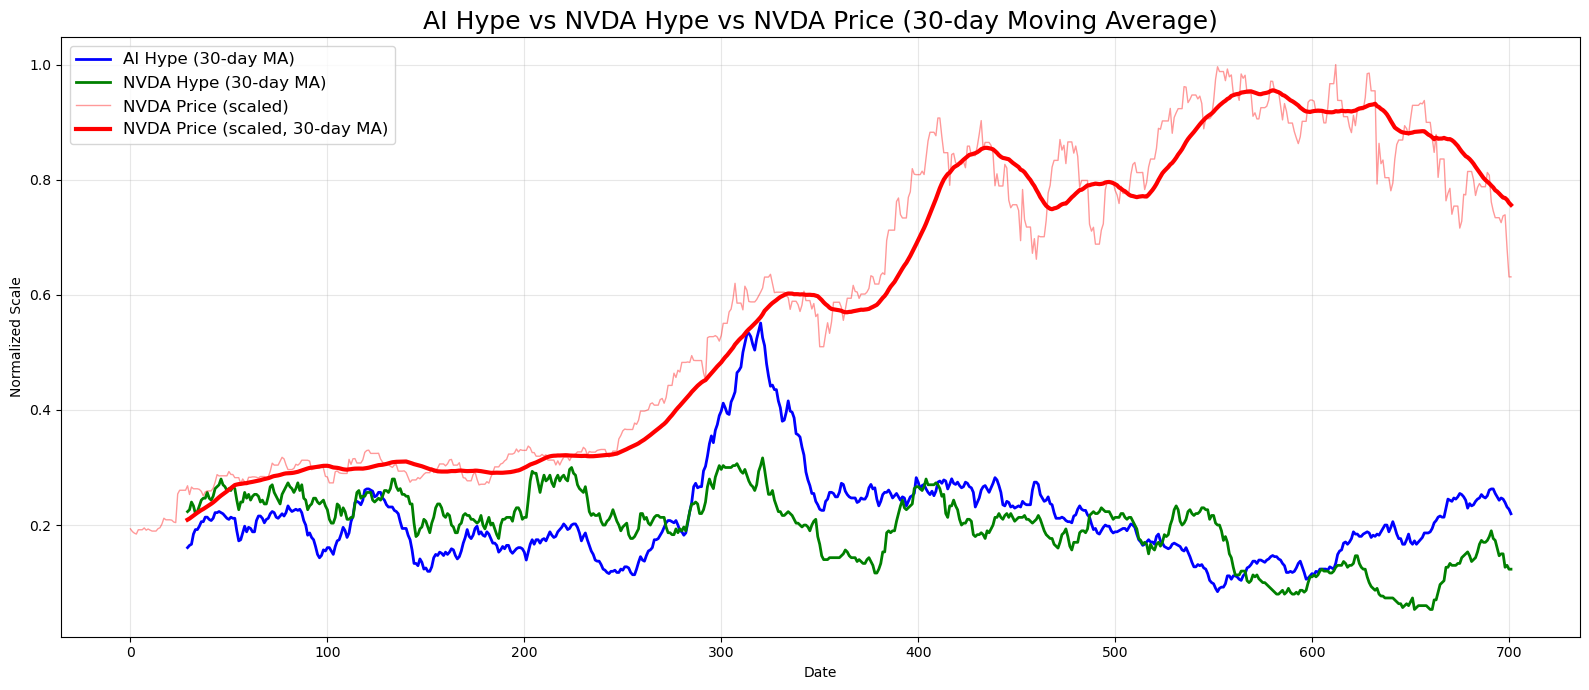

In [ ]:
# -------------------------------------------------------------
# FIX — Fill missing NVDA price values
# -------------------------------------------------------------
merged["NVDA_Close"] = merged["NVDA_Close"].ffill()

# 1. Moving averages for hype indexes
merged["AI_ma30"] = merged["AI_norm"].rolling(30).mean()
merged["NVDA_ma30"] = merged["NVDA_norm"].rolling(30).mean()

# 2. Scale NVDA price
merged["NVDA_price_scaled"] = merged["NVDA_Close"] / merged["NVDA_Close"].max()
merged["NVDA_price_ma30"] = merged["NVDA_price_scaled"].rolling(30).mean()

# 3. Plot
plt.figure(figsize=(16,7))

plt.plot(merged.index, merged["AI_ma30"],
         label="AI Hype (30-day MA)", color="blue", linewidth=2)

plt.plot(merged.index, merged["NVDA_ma30"],
         label="NVDA Hype (30-day MA)", color="green", linewidth=2)

plt.plot(merged.index, merged["NVDA_price_scaled"],
         label="NVDA Price (scaled)", color="red", linewidth=1, alpha=0.4)

plt.plot(merged.index, merged["NVDA_price_ma30"],
         label="NVDA Price (scaled, 30-day MA)", color="red", linewidth=3)

plt.title("AI Hype vs NVDA Hype vs NVDA Price (30-day Moving Average)", fontsize=18)
plt.xlabel("Date")
plt.ylabel("Normalized Scale")
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


нужно считать долю новостей для берт топки

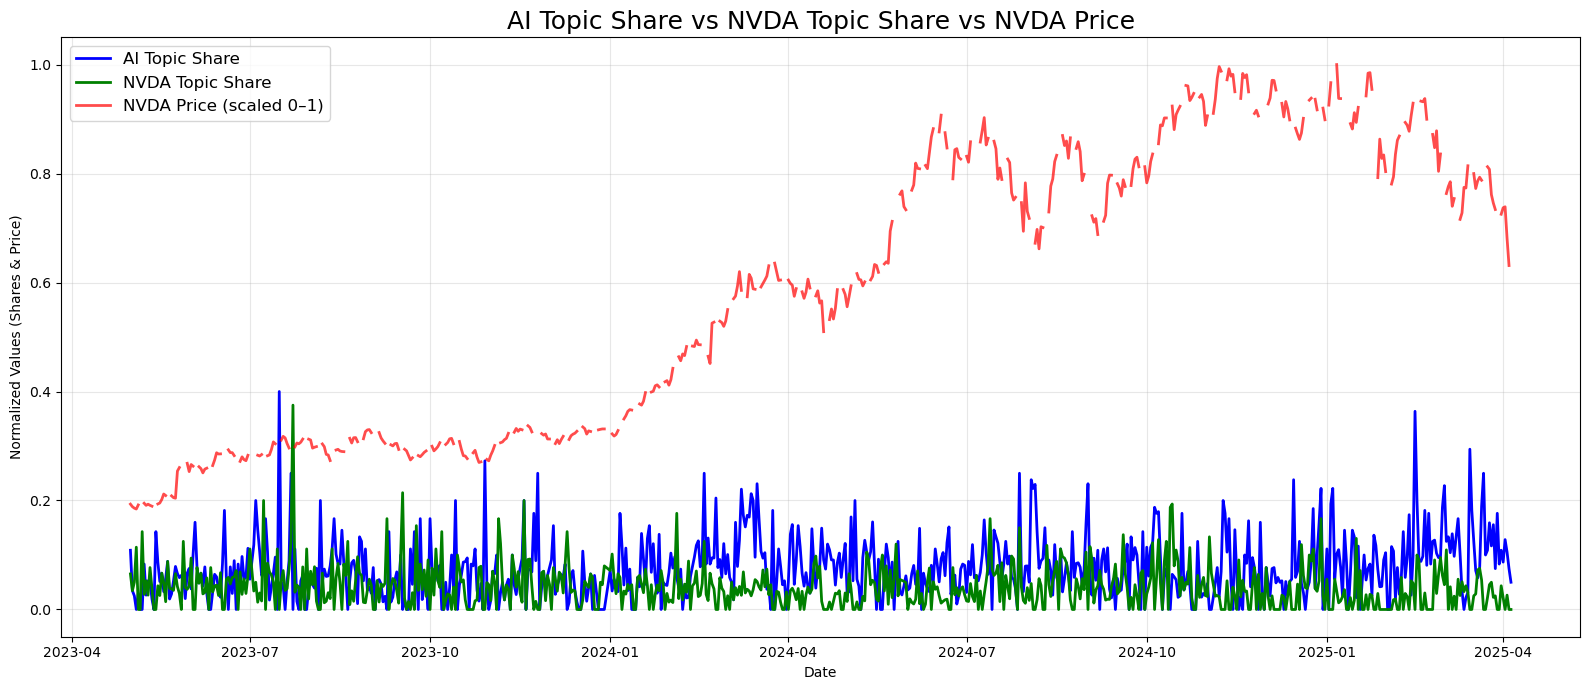

In [ ]:
# -------------------------------------------------
# 1. Готовим BERTopic hype-метрики
# -------------------------------------------------

daily = daily_counts.copy()

# Доля AI новостей в общем объёме
daily["AI_share"] = daily["AI_news"] / (
    daily["AI_news"] + daily["NVDA_news"] + daily["Other_news"]
)

# Доля NVDA новостей в общем объёме
daily["NVDA_share"] = daily["NVDA_news"] / (
    daily["AI_news"] + daily["NVDA_news"] + daily["Other_news"]
)

# Доля прочих (Other) новостей в общем объёме
daily["Other_share"] = daily["Other_news"] / (
    daily["AI_news"] + daily["NVDA_news"] + daily["Other_news"]
)

# Проверка на NaN — заменяем редкие пустые дни нулями
daily[["AI_share", "NVDA_share", "Other_share"]] = (
    daily[["AI_share", "NVDA_share", "Other_share"]].fillna(0)
)


# -------------------------------------------------
# 2. Объединяем BERTopic + NVDA Price
# -------------------------------------------------

df_nvda_price["date_only"] = pd.to_datetime(df_nvda_price["date_only"])
merged = pd.merge(daily, df_nvda_price, on="date_only", how="left")

# Нормируем цену (для графика)
merged["NVDA_price_scaled"] = merged["NVDA_Close"] / merged["NVDA_Close"].max()

merged.to_csv("Merged.csv")
# -------------------------------------------------
# 3. Строим график: AI share, NVDA share, NVDA price
# -------------------------------------------------

plt.figure(figsize=(16,7))

plt.plot(merged["date_only"], merged["AI_share"],
         label="AI Topic Share", color="blue", linewidth=2)

plt.plot(merged["date_only"], merged["NVDA_share"],
         label="NVDA Topic Share", color="green", linewidth=2)

#plt.plot(merged["date_only"], merged["Other_share"],
 #        label="Other Topic Share", color="yellow", linewidth=2)

plt.plot(merged["date_only"], merged["NVDA_price_scaled"],
         label="NVDA Price (scaled 0–1)", color="red", linewidth=2, alpha=0.7)

plt.title("AI Topic Share vs NVDA Topic Share vs NVDA Price", fontsize=18)
plt.xlabel("Date")
plt.ylabel("Normalized Values (Shares & Price)")
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
merged.to_csv("Merged")

In [ ]:
corr_matrix = merged[["AI_share", "NVDA_share", "NVDA_Close"]].corr()

print("=== Pearson Correlation with NVDA Price ===")
print(corr_matrix)


=== Pearson Correlation with NVDA Price ===
            AI_share  NVDA_share  NVDA_Close
AI_share    1.000000   -0.119179    0.170676
NVDA_share -0.119179    1.000000   -0.096684
NVDA_Close  0.170676   -0.096684    1.000000


In [ ]:
import numpy as np
merged["log_price"] = np.log(merged["NVDA_Close"])

corr_log = merged[["AI_share", "NVDA_share", "log_price"]].corr()

print("=== Correlation with Log Price ===")
print(corr_log)


=== Correlation with Log Price ===
            AI_share  NVDA_share  log_price
AI_share    1.000000   -0.119179   0.199923
NVDA_share -0.119179    1.000000  -0.105753
log_price   0.199923   -0.105753   1.000000


In [ ]:
merged["NVDA_return"] = merged["NVDA_Close"].pct_change()

corr_returns = merged[["AI_share", "NVDA_share", "NVDA_return"]].corr()

print("=== Correlation with Returns ===")
print(corr_returns)


=== Correlation with Returns ===
             AI_share  NVDA_share  NVDA_return
AI_share     1.000000   -0.119179    -0.046330
NVDA_share  -0.119179    1.000000    -0.015025
NVDA_return -0.046330   -0.015025     1.000000


In [ ]:
import pandas as pd

lags = range(0, 8)
results = []

for lag in lags:
    corr = merged["AI_share"].shift(lag).corr(merged["NVDA_return"])
    results.append({"lag": lag, "corr_AI": corr})

    corr2 = merged["NVDA_share"].shift(lag).corr(merged["NVDA_return"])
    results[-1]["corr_NVDA"] = corr2

lag_corr_df = pd.DataFrame(results)
print(lag_corr_df)


   lag   corr_AI  corr_NVDA
0    0 -0.046330  -0.015025
1    1 -0.049410   0.062533
2    2 -0.066558  -0.006036
3    3 -0.002908   0.016027
4    4 -0.038395   0.030660
5    5 -0.017726   0.091123
6    6 -0.026770  -0.014795
7    7 -0.025384   0.010691


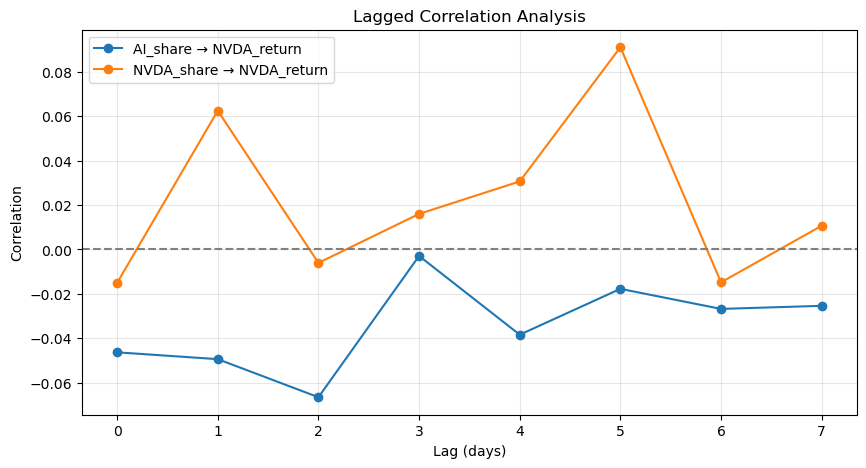

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(lag_corr_df["lag"], lag_corr_df["corr_AI"], marker='o', label="AI_share → NVDA_return")
plt.plot(lag_corr_df["lag"], lag_corr_df["corr_NVDA"], marker='o', label="NVDA_share → NVDA_return")

plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Lag (days)")
plt.ylabel("Correlation")
plt.title("Lagged Correlation Analysis")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests

# --- 1. Создаем доходность ---
merged["NVDA_return"] = merged["NVDA_Close"].pct_change()
merged = merged.dropna(subset=["NVDA_return"])

# --- 2. Подготовка данных ---
# Granger требует формат: колонка Y, колонка X
df_gc = merged[["NVDA_return", "AI_share", "NVDA_share"]].dropna()

# --- 3. Функция удобного вывода ---
def run_granger_test(df, cause, maxlag=7):
    print(f"\n==============================")
    print(f"   GRANGER TEST: {cause} → NVDA_return")
    print(f"==============================")

    result = grangercausalitytests(
        df[["NVDA_return", cause]],
        maxlag=maxlag,
        verbose=False
    )

    for lag in range(1, maxlag+1):
        p_value = result[lag][0]["ssr_ftest"][1]
        print(f"Lag {lag}: p-value = {p_value:.4f}")

    print("Conclusion:",
          "CAUSES" if any(result[lag][0]["ssr_ftest"][1] < 0.05
                          for lag in range(1, maxlag+1))
          else "NO CAUSALITY detected")

# --- 4. Тестируем ---
run_granger_test(df_gc, "AI_share", maxlag=7)
run_granger_test(df_gc, "NVDA_share", maxlag=7)



   GRANGER TEST: AI_share → NVDA_return
Lag 1: p-value = 0.1669
Lag 2: p-value = 0.0999
Lag 3: p-value = 0.1915
Lag 4: p-value = 0.2966
Lag 5: p-value = 0.4261
Lag 6: p-value = 0.4955
Lag 7: p-value = 0.6293
Conclusion: NO CAUSALITY detected

   GRANGER TEST: NVDA_share → NVDA_return
Lag 1: p-value = 0.0988
Lag 2: p-value = 0.2534
Lag 3: p-value = 0.4061
Lag 4: p-value = 0.5920
Lag 5: p-value = 0.1507
Lag 6: p-value = 0.2064
Lag 7: p-value = 0.3070
Conclusion: NO CAUSALITY detected


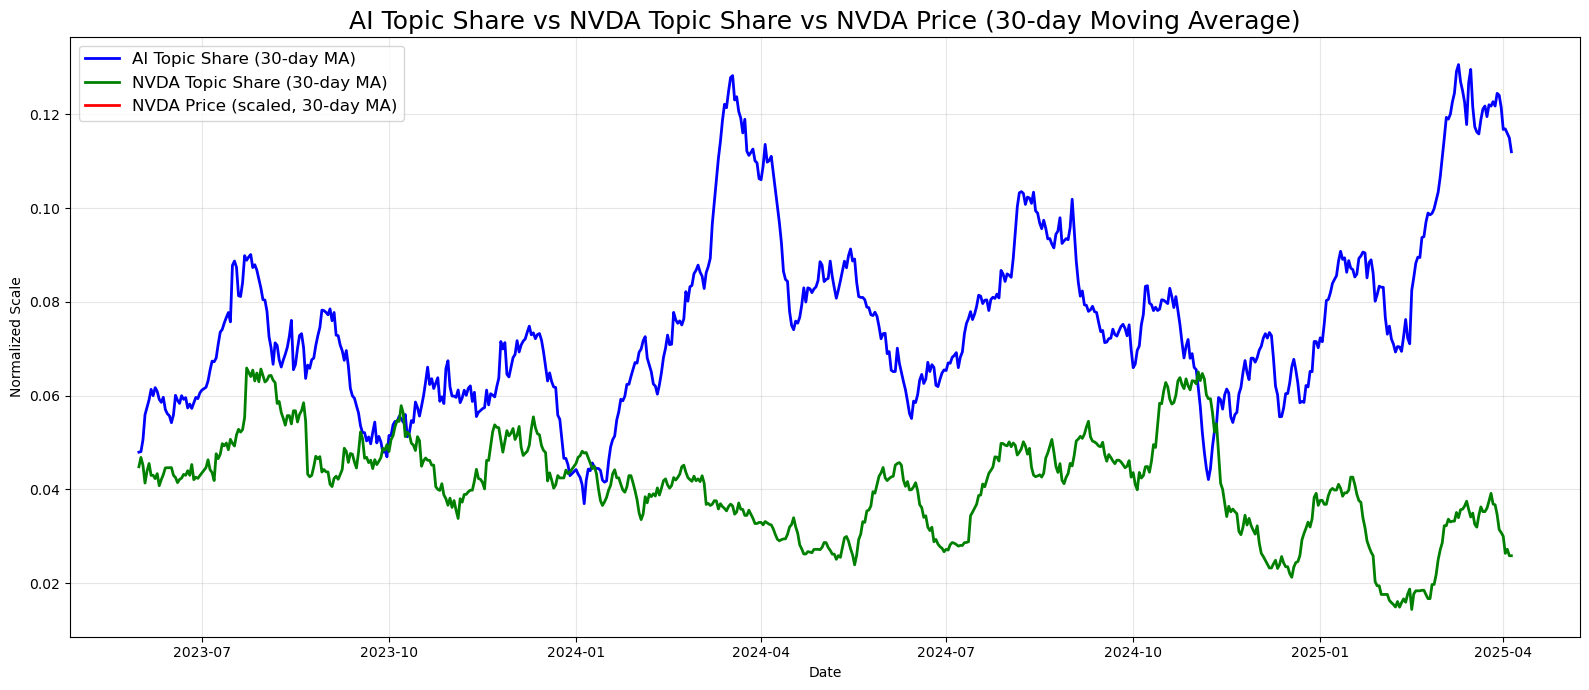

In [ ]:
# -------------------------------------------------
# 1. 30-day Moving Averages
# -------------------------------------------------

merged["AI_share_MA30"] = merged["AI_share"].rolling(30).mean()
merged["NVDA_share_MA30"] = merged["NVDA_share"].rolling(30).mean()

# Масштабируем и сглаживаем цену NVDA
merged["NVDA_price_scaled"] = merged["NVDA_Close"] / merged["NVDA_Close"].max()
merged["NVDA_price_MA30"] = merged["NVDA_price_scaled"].rolling(30).mean()


# -------------------------------------------------
# 2. Plot
# -------------------------------------------------
plt.figure(figsize=(16,7))

# AI share
plt.plot(merged["date_only"], merged["AI_share_MA30"],
         label="AI Topic Share (30-day MA)", color="blue", linewidth=2)

# NVDA share
plt.plot(merged["date_only"], merged["NVDA_share_MA30"],
         label="NVDA Topic Share (30-day MA)", color="green", linewidth=2)

# NVDA Price (smoothed)
plt.plot(merged["date_only"], merged["NVDA_price_MA30"],
         label="NVDA Price (scaled, 30-day MA)", color="red", linewidth=2)

plt.title("AI Topic Share vs NVDA Topic Share vs NVDA Price (30-day Moving Average)", fontsize=18)
plt.xlabel("Date")
plt.ylabel("Normalized Scale")
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
daily = daily_counts.copy()

# Переносим индекс в колонку date_only
daily["date_only"] = daily.index
daily.columns

Index(['AI_news', 'NVDA_news', 'Other_news', 'date_only'], dtype='object')

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ============= 1. HYPE METRICS =============
daily = daily_counts.copy()

# переносим индекс в колонку с датой
daily["date_only"] = daily.index
daily["date_only"] = pd.to_datetime(daily["date_only"])

# Доля AI новостей
daily["AI_share"] = daily["AI_news"] / (
    daily["AI_news"] + daily["NVDA_news"] + daily["Other_news"]
)

# Доля NVDA новостей
daily["NVDA_share"] = daily["NVDA_news"] / (
    daily["AI_news"] + daily["NVDA_news"] + daily["Other_news"]
)

daily["AI_share"] = daily["AI_share"].fillna(0)
daily["NVDA_share"] = daily["NVDA_share"].fillna(0)


# ============= 2. ALIGN DATES =============
# создаём полный календарь
full_dates = pd.DataFrame({"date_only": pd.date_range(
    start=daily["date_only"].min(),
    end=daily["date_only"].max(),
    freq="D"
)})

# объединяем
daily_full = pd.merge(full_dates, daily, on="date_only", how="left")

# заполняем пропуски тем же днём (0 новостей в пропущенные дни)
daily_full[["AI_share", "NVDA_share"]] = daily_full[["AI_share", "NVDA_share"]].fillna(0)


# ============= 3. MERGE WITH NVDA PRICE =============
df_nvda_price["date_only"] = pd.to_datetime(df_nvda_price["date_only"])

merged = pd.merge(daily_full, df_nvda_price, on="date_only", how="left")

# интерполируем цену → чтобы линия была ровной
merged["NVDA_Close"] = merged["NVDA_Close"].interpolate()

# масштабируем к 0–1
merged["NVDA_price_scaled"] = merged["NVDA_Close"] / merged["NVDA_Close"].max()


# ============= 4. MA-30 для красивой линии =============
merged["AI_MA30"] = merged["AI_share"].rolling(30).mean()
merged["NVDA_MA30"] = merged["NVDA_share"].rolling(30).mean()
merged["Price_MA30"] = merged["NVDA_price_scaled"].rolling(30).mean()


# ============= 5. PLOT =============
plt.figure(figsize=(16,7))

plt.plot(merged["date_only"], merged["AI_MA30"],
         label="AI Topic Share (MA-30)", linewidth=2, color="blue")

plt.plot(merged["date_only"], merged["NVDA_MA30"],
         label="NVDA Topic Share (MA-30)", linewidth=2, color="green")

plt.plot(merged["date_only"], merged["Price_MA30"],
         label="NVDA Price (scaled, MA-30)", linewidth=2.5, color="red")

plt.title("AI Topic Share vs NVDA Topic Share vs NVDA Price (Smoothed MA-30)", fontsize=18)
plt.xlabel("Date")
plt.ylabel("Normalized Scale")
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


ValueError: 'date_only' is both an index level and a column label, which is ambiguous.

In [ ]:
daily_counts.columns
